In [1]:
import torch

from transformers import pipeline
from transformers import AutoModelForCausalLM
from transformers import AutoTokenizer, AutoModelForCausalLM, GenerationConfig

In [2]:
model_name = "Qwen/Qwen1.5-MoE-A2.7B"
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True,)
model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=torch.bfloat16, trust_remote_code=True, device_map="auto")
# model.generation_config = GenerationConfig.from_pretrained(model_name)
# model.generation_config.pad_token_id = model.generation_config.eos_token_id
# model = AutoModelForCausalLM.from_pretrained(model_name, trust_remote_code=True, device_map="auto")

Loading checkpoint shards:   0%|          | 0/8 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.


The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


=== torch.Size([692, 1]) torch.Size([692, 692])


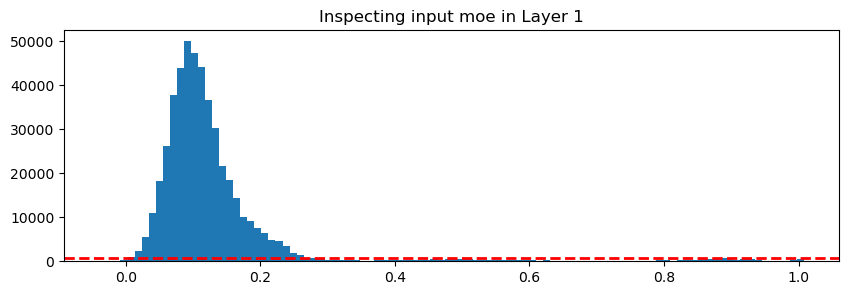

=== torch.Size([60, 1]) torch.Size([60, 60])


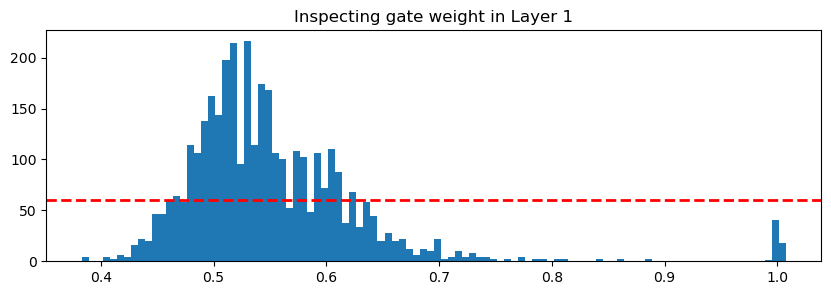

> /home/reiase/workspace/transformers/src/transformers/models/qwen2_moe/modeling_qwen2_moe.py(641)forward()
    640         import ipdb; ipdb.set_trace()
--> 641         routing_weights, selected_experts = torch.topk(routing_weights, self.top_k, dim=-1)
    642         if self.norm_topk_prob:



ipdb>  router_logits


tensor([[-10.1250, -10.7500, -10.3750,  ...,  -9.8125, -12.7500, -14.5625],
        [ -4.4688,  -3.8125,  -4.4062,  ...,  -3.9531,  -5.6875,  -5.5625],
        [ -4.3750,  -4.6562,  -4.8125,  ...,  -4.8125,  -4.4688,  -6.1250],
        ...,
        [ -6.5938,  -6.7500,  -7.5000,  ...,  -7.5312,  -7.0312,  -6.6562],
        [ -3.5625,  -4.0938,  -3.4531,  ...,  -3.4375,  -5.1562,  -4.9688],
        [ -3.8906,  -4.0625,  -3.9375,  ...,  -3.9219,  -4.5625,  -6.1875]],
       device='cuda:0', dtype=torch.bfloat16)


ipdb>  iimport matplotlib.pyplot as plt


*** SyntaxError: invalid syntax


...

ipdb>  plt.hist(router_logits.cpu(), bins=50)


*** TypeError: Got unsupported ScalarType BFloat16


ipdb>  plt.hist(router_logits.to(torch.float32).cpu(), bins=50)


(array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       ...,
       [0., 0., 0., ..., 2., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]]), array([-15.1875    , -14.87257767, -14.55765629, -14.24273396,
       -13.92781258, -13.61289024, -13.29796886, -12.98304653,
       -12.66812515, -12.35320282, -12.03828144, -11.72335911,
       -11.40843773, -11.0935154 , -10.77859306, -10.46367168,
       -10.14875031,  -9.83382797,  -9.51890564,  -9.20398426,
        -8.88906288,  -8.57414055,  -8.25921822,  -7.94429684,
        -7.6293745 ,  -7.31445265,  -6.99953079,  -6.68460941,
        -6.36968708,  -6.0547657 ,  -5.73984337,  -5.42492199,
        -5.10999966,  -4.79507732,  -4.48015594,  -4.16523361,
        -3.85031223,  -3.5353899 ,  -3.22046852,  -2.90554619,
        -2.59062481,  -2.27570248,  -1.9607811 ,  -1.64585876,
        -1.33093739,  -1.01601505,  -0.70109367,  -0.38617134,
 

ipdb>  plt.show()


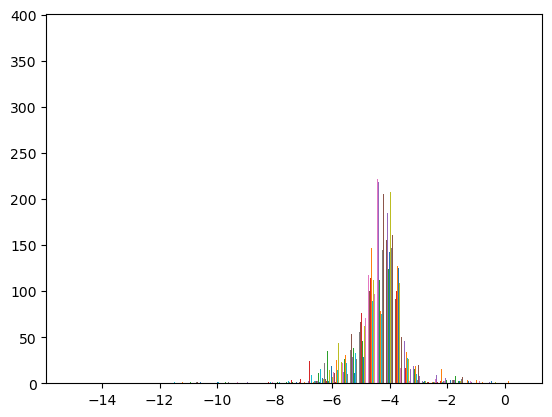

ipdb>  plt.hist(router_logits.to(torch.float32).flatten().cpu(), bins=50)


(array([1.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 2.000e+00, 3.000e+00, 1.000e+00, 1.000e+00, 5.000e+00,
       8.000e+00, 1.100e+01, 1.100e+01, 8.000e+00, 1.200e+01, 5.000e+00,
       4.000e+00, 3.000e+00, 1.100e+01, 7.000e+00, 1.000e+01, 8.000e+00,
       3.500e+01, 7.300e+01, 1.810e+02, 2.710e+02, 5.270e+02, 9.720e+02,
       1.718e+03, 2.782e+03, 3.938e+03, 6.193e+03, 8.344e+03, 8.478e+03,
       4.785e+03, 1.325e+03, 4.760e+02, 2.670e+02, 2.570e+02, 2.200e+02,
       1.740e+02, 1.700e+02, 1.300e+02, 5.300e+01, 2.400e+01, 1.000e+01,
       3.000e+00, 1.000e+00]), array([-15.1875    , -14.87257767, -14.55765629, -14.24273396,
       -13.92781258, -13.61289024, -13.29796886, -12.98304653,
       -12.66812515, -12.35320282, -12.03828144, -11.72335911,
       -11.40843773, -11.0935154 , -10.77859306, -10.46367168,
       -10.14875031,  -9.83382797,  -9.51890564,  -9.20398426,
        -8.88906288,  -8.57414055,  -8.25921822,  -7.94429684,
      

ipdb>  plt.show()


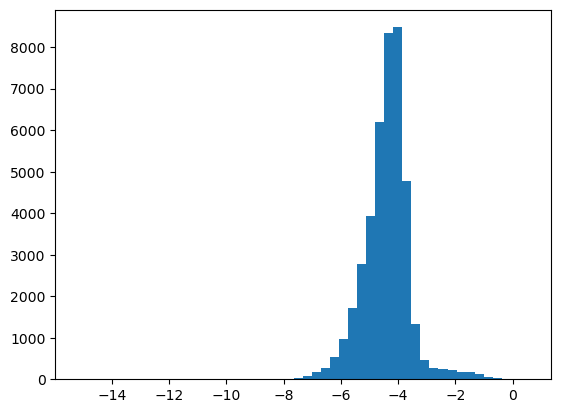

ipdb>  plt.hist(router_weights.to(torch.float32).flatten().cpu(), bins=50)


*** NameError: name 'router_weights' is not defined


ipdb>  plt.hist(routing_weights.to(torch.float32).flatten().cpu(), bins=50)


(array([3.2966e+04, 6.9120e+03, 4.6100e+02, 2.5400e+02, 1.7200e+02,
       1.2100e+02, 9.9000e+01, 9.8000e+01, 8.7000e+01, 6.8000e+01,
       6.0000e+01, 4.4000e+01, 3.1000e+01, 3.5000e+01, 2.7000e+01,
       2.3000e+01, 1.3000e+01, 1.2000e+01, 1.0000e+01, 6.0000e+00,
       4.0000e+00, 2.0000e+00, 5.0000e+00, 0.0000e+00, 3.0000e+00,
       1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00, 1.0000e+00,
       1.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
       0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00]), array([7.93044546e-06, 1.91913769e-02, 3.83748226e-02, 5.75582683e-02,
       7.67417103e-02, 9.59251523e-02, 1.15108602e-01, 1.34292051e-01,
       1.53475493e-01, 1.72658935e-01, 1.91842377e-01, 2.11025834e-01,
       2.30209276e-01, 2.49392718e-01, 2.68576175e-01, 2.87759602e-01,
       3.06943059e-01, 3.26126516e-01, 3.45

ipdb>  plt.show()


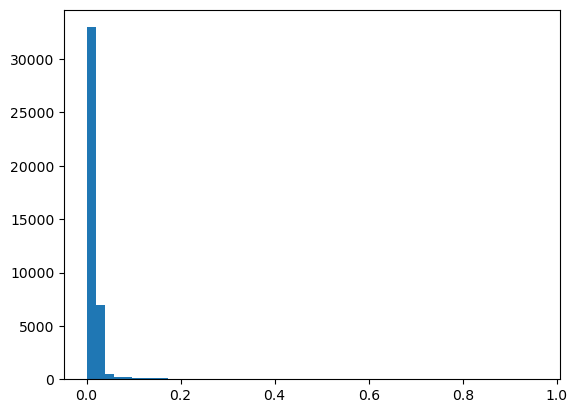

--KeyboardInterrupt--

KeyboardInterrupt: Interrupted by user
=== torch.Size([41, 1]) torch.Size([41, 41])


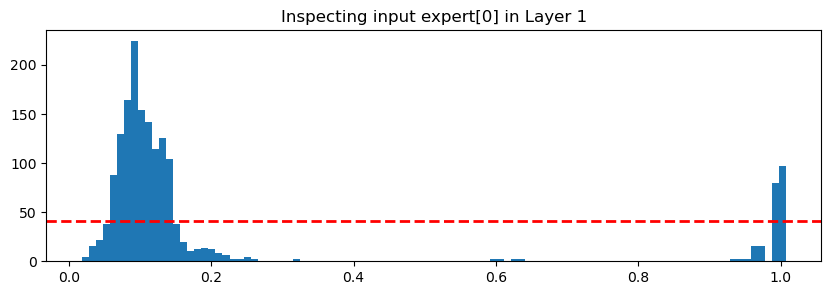

/home/reiase/workspace/transformers/src/transformers/models/inspect.py:317: RuntimeWarning: invalid value encountered in sqrt
  np.sqrt((b - x) * (x - a)) / (2 * np.pi * sigma_squared * c * x),


In [ ]:
messages = [
    { "role":"user", "content": """
先帝创业未半而中道崩殂，今天下三分，益州疲弊，此诚危急存亡之秋也。然侍卫之臣不懈于内，忠志之士忘身于外者，盖追先帝之殊遇，欲报之于陛下也。诚宜开张圣听，以光先帝遗德，恢弘志士之气，不宜妄自菲薄，引喻失义，以塞忠谏之路也。
宫中府中，俱为一体；陟罚臧否，不宜异同。若有作奸犯科及为忠善者，宜付有司论其刑赏，以昭陛下平明之理，不宜偏私，使内外异法也。
侍中、侍郎郭攸之、费祎、董允等，此皆良实，志虑忠纯，是以先帝简拔以遗陛下。愚以为宫中之事，事无大小，悉以咨之，然后施行，必能裨补阙漏，有所广益。
将军向宠，性行淑均，晓畅军事，试用于昔日，先帝称之曰能，是以众议举宠为督。愚以为营中之事，悉以咨之，必能使行阵和睦，优劣得所。
亲贤臣，远小人，此先汉所以兴隆也；亲小人，远贤臣，此后汉所以倾颓也。先帝在时，每与臣论此事，未尝不叹息痛恨于桓、灵也。侍中、尚书、长史、参军，此悉贞良死节之臣，愿陛下亲之信之，则汉室之隆，可计日而待也。
臣本布衣，躬耕于南阳，苟全性命于乱世，不求闻达于诸侯。先帝不以臣卑鄙，猥自枉屈，三顾臣于草庐之中，咨臣以当世之事，由是感激，遂许先帝以驱驰。后值倾覆，受任于败军之际，奉命于危难之间，尔来二十有一年矣。
先帝知臣谨慎，故临崩寄臣以大事也。受命以来，夙夜忧叹，恐托付不效，以伤先帝之明；故五月渡泸，深入不毛。今南方已定，兵甲已足，当奖率三军，北定中原，庶竭驽钝，攘除奸凶，兴复汉室，还于旧都。此臣所以报先帝而忠陛下之职分也。至于斟酌损益，进尽忠言，则攸之、祎、允之任也。
愿陛下托臣以讨贼兴复之效，不效，则治臣之罪，以告先帝之灵。若无兴德之言，则责攸之、祎、允等之慢，以彰其咎；陛下亦宜自谋，以咨诹善道，察纳雅言，深追先帝遗诏。臣不胜受恩感激。今当远离，临表涕零，不知所言。
    """},
]

input_tensor = tokenizer.apply_chat_template(messages, add_generation_prompt=True, return_tensors="pt")
outputs = model.generate(input_tensor.to(model.device), max_new_tokens=100)

result = tokenizer.decode(outputs[0][input_tensor.shape[1]:], skip_special_tokens=True)
print(result)